主体参考transformer for vision;
学习运用编码器(Encoder)部分,完成Fashion-MNIST数据集分类任务
![ViT架构](ViT.png)

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## Patch Embedding

将图像分割成多个片段和线性 将这些扁平化的斑块投影为一个整体 卷积运算，其中核大小和步幅均为 设置为补丁大小。

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=96, patch_size=16, num_hiddens=512):
        super().__init__()
        
        # 内部工具函数 _make_tuple
        def _make_tuple(x):
            if not isinstance(x, (list, tuple)):
                return (x, x)
            return x
        img_size, patch_size = _make_tuple(img_size), _make_tuple(patch_size)
        
        # 计算 patch 总数 self.num_patches
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        
        # 卷积层 nn.LazyConv2d
        # kernel_size=patch_size：卷积核大小等于 patch 尺寸，一次卷积刚好覆盖一个完整 patch
        # stride=patch_size：步长等于 patch 尺寸，卷积窗口不重叠、无空隙，完美切分图像
        # out_channels=num_hiddens：每个 patch 卷积输出通道数 = 隐藏维度，等价于对 patch 像素做线性映射
        self.conv = nn.LazyConv2d(num_hiddens, kernel_size=patch_size,stride=patch_size)

    def forward(self, X):
        # 设输入图片 X.shape = (B, C, H, W)
        # B：batch 批次大小，C：图像通道 (3/RGB)，H/W：图像高宽
        # Output shape: (batch size, no. of patches, no. of channels)
        return self.conv(X).flatten(2).transpose(1, 2)


遇到报错:
```
AttributeError                            Traceback (most recent call last)
Cell In[4], line 4
      2 patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
      3 X = torch.zeros(batch_size, 3, img_size, img_size)
----> 4 d2l.check_shape(patch_emb(X),
      5                 (batch_size, (img_size//patch_size)**2, num_hiddens))

AttributeError: module 'd2l.torch' has no attribute 'check_shape'
```
原因:
新版 d2l.torch（d2l-pytorch）移除 / 重命名了 check_shape 函数，因此直接调用会报属性错误。

In [3]:
# 定义一个新的函数
def check_shape(tensor, expected):
    if tuple(tensor.shape) != expected:
        raise RuntimeError(f"实际shape: {tuple(tensor.shape)}, 预期shape: {expected}")

img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4  # batch_size=4：一批 4 张图片
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
X = torch.zeros(batch_size, 3, img_size, img_size)
check_shape(patch_emb(X),
                (batch_size, (img_size//patch_size)**2, num_hiddens))

/home/ppxww/miniconda3/envs/d2l/lib/python3.9/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


## Vision Transformer Encoder

The MLP of the vision Transformer encoder is slightly different from the positionwise FFN of the original Transformer encoder 

视觉 Transformer 编码器中的多层感知机（MLP），与原始 Transformer 编码器的逐位置前馈网络（FFN）存在细微差异。

First, here the activation function uses the Gaussian error linear unit (GELU), which can be considered as a smoother version of the ReLU 

首先，这里使用 ** 高斯误差线性单元（GELU）** 作为激活函数，它可以看作是 ReLU 的平滑版本。

Second, dropout is applied to the output of each fully connected layer in the MLP for regularization.

其次，该多层感知机（MLP）中每个全连接层的输出都会应用 ** dropout** 以实现正则化。

In [4]:
# 线性升维 → GELU 激活 → Dropout → 线性降维 → Dropout。
class ViTMLP(nn.Module):
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout=0.5):
        super().__init__()
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout2(self.dense2(self.dropout1(self.gelu(self.dense1(x)))))


```
AttributeError                            Traceback (most recent call last)
Cell In[51], line 4
      2 num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
      3 emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
----> 4 model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
      5             num_blks, emb_dropout, blk_dropout, lr)
      6 trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
      7 data = d2l.FashionMNIST(batch_size=128, resize=(img_size, img_size))

Cell In[48], line 18, in ViT.__init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads, num_blks, emb_dropout, blk_dropout, lr, use_bias, num_classes)
     16 self.blks = nn.Sequential()
     17 for i in range(num_blks):
---> 18     self.blks.add_module(f"{i}", ViTBlock(
     19         num_hiddens, num_hiddens, mlp_num_hiddens,
     20         num_heads, blk_dropout, use_bias))
     21 self.head = nn.Sequential(nn.LayerNorm(num_hiddens),
     22                           nn.Linear(num_hiddens, num_classes))

Cell In[39], line 8, in ViTBlock.__init__(self, num_hiddens, norm_shape, mlp_num_hiddens, num_heads, dropout, use_bias)
      6 self.ln1 = nn.LayerNorm(norm_shape)
      7 # 多头自注意力
----> 8 self.attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,# Q,K,V
      9                                     num_hiddens, num_heads, dropout, use_bias)
     10 # 层归一化
     11 self.ln2 = nn.LayerNorm(norm_shape)

Cell In[38], line 8, in MultiHeadAttention.__init__(self, key_size, query_size, value_size, num_hiddens, num_heads, dropout, bias, **kwargs)
      6 self.num_heads = num_heads
      7 # d2l.DotProductAttention(dropout):框架中实现点积注意力（Dot-Product Attention） 的核心类; 详情见第三节
----> 8 self.attention = d2l.DotProductAttention(dropout)
      9 self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
     10 self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)

AttributeError: module 'd2l' has no attribute 'DotProductAttention'
```
报错原因
新版 d2l（d2l-pytorch）把 DotProductAttention 改名 / 迁移了，不再直接 d2l.DotProductAttention

### 自己实现 DotProductAttention

In [5]:
class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries: (batch, q_len, d)
    # keys: (batch, k_len, d)
    # values: (batch, k_len, v_dim)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # 点积分数 / sqrt(d)
        scores = torch.bmm(queries, keys.transpose(1,2)) / torch.sqrt(torch.tensor(d, dtype=torch.float32))
        if valid_lens is not None:
            # 掩码填充
            max_len = scores.shape[-1]
            mask = torch.arange(max_len, device=scores.device)[None, :] < valid_lens[:, None]
            scores[~mask] = -1e6
        attn_weights = nn.functional.softmax(scores, dim=-1)
        return torch.bmm(self.dropout(attn_weights), values)

### MultiHeadAttention
重新定义该模块，绕过d2l包，方便后续修改

In [6]:
class MultiHeadAttention(nn.Module):
    """多头注意力"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        # d2l.DotProductAttention(dropout):框架中实现点积注意力（Dot-Product Attention） 的核心类; 详情见第三节
        # self.attention = d2l.DotProductAttention(dropout)
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # queries，keys，values的形状:
        # (batch_size，查询或者“键－值”对的个数，num_hiddens)
        # valid_lens　的形状:
        # (batch_size，)或(batch_size，查询的个数)
        # 经过变换后，输出的queries，keys，values　的形状:
        # (batch_size*num_heads，查询或者“键－值”对的个数，
        # num_hiddens/num_heads)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # 在轴0，将第一项（标量或者矢量）复制num_heads次，
            # 然后如此复制第二项，然后诸如此类。
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # output的形状:(batch_size*num_heads，查询的个数，
        # num_hiddens/num_heads)
        output = self.attention(queries, keys, values, valid_lens)

        # output_concat的形状:(batch_size，查询的个数，num_hiddens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)
    
def transpose_qkv(X, num_heads):
    """为了多注意力头的并行计算而变换形状"""
    # 输入X的形状:(batch_size，查询或者“键－值”对的个数，num_hiddens)
    # 输出X的形状:(batch_size，查询或者“键－值”对的个数，num_heads，
    # num_hiddens/num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # 输出X的形状:(batch_size，num_heads，查询或者“键－值”对的个数,
    # num_hiddens/num_heads)
    X = X.permute(0, 2, 1, 3)

    # 最终输出的形状:(batch_size*num_heads,查询或者“键－值”对的个数,
    # num_hiddens/num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])


#@save
def transpose_output(X, num_heads):
    """逆转transpose_qkv函数的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [7]:
class ViTBlock(nn.Module):
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens,
                 num_heads, dropout, use_bias=False):
        super().__init__()
        # 层归一化
        self.ln1 = nn.LayerNorm(norm_shape)
        # 多头自注意力
        self.attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,# Q,K,V
                                            num_hiddens, num_heads, dropout, use_bias)
        # 层归一化
        self.ln2 = nn.LayerNorm(norm_shape)
        # MLP
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout)

    def forward(self, X, valid_lens=None):
        # 多头注意力 + 残差连接
        X = X + self.attention(*([self.ln1(X)] * 3), valid_lens)
        # MLP + 残差连接
        return X + self.mlp(self.ln2(X))
    # self.ln1(X)          # 先对输入做层归一化 Pre-LN
    # [self.ln1(X)] * 3    # 生成 [ln_X, ln_X, ln_X] 列表，对应 Q, K, V
    # *()                  # 解包传入MultiHeadAttention，实现自注意力 Q=K=V
    # X + attention_out    # 残差连接：原始输入 + 注意力输出

In [8]:
X = torch.ones((2, 100, 24))
encoder_blk = ViTBlock(24, 24, 48, 8, 0.5)
encoder_blk.eval()
check_shape(encoder_blk(X), X.shape)

报错
```
TypeError                                 Traceback (most recent call last)
Cell In[20], line 2
      1 X = torch.ones((2, 100, 24))
----> 2 encoder_blk = ViTBlock(24, 24, 48, 8, 0.5)
      3 encoder_blk.eval()
      4 d2l.check_shape(encoder_blk(X), X.shape)

Cell In[19], line 8, in ViTBlock.__init__(self, num_hiddens, norm_shape, mlp_num_hiddens, num_heads, dropout, use_bias)
      6 self.ln1 = nn.LayerNorm(norm_shape)
      7 # 多头自注意力
----> 8 self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads,
      9                                         dropout, use_bias)
     10 # 层归一化
     11 self.ln2 = nn.LayerNorm(norm_shape)

TypeError: __init__() missing 2 required positional arguments: 'num_heads' and 'dropout'
```
原因：多头注意力模块出错


## Putting It All Together

The forward pass of vision Transformers below is straightforward. First, input images are fed into an PatchEmbedding instance, whose output is concatenated with the “<cls>” token embedding. They are summed with learnable positional embeddings before dropout. Then the output is fed into the Transformer encoder that stacks num_blks instances of the ViTBlock class. Finally, the representation of the “<cls>” token is projected by the network head.
    
下面介绍视觉 Transformer 的前向传播过程，流程十分直观。首先，输入图像送入分块嵌入层，其输出与 ** 类别标记（<cls>）** 的嵌入向量拼接；随后二者与可学习的位置嵌入相加，再执行丢弃操作。接着，结果送入由num_blks个视觉 Transformer 块堆叠而成的 Transformer 编码器。最后，类别标记（<cls>）对应的特征表示经由分类头网络完成映射输出。

In [9]:
# 检查版本
import d2l
print(d2l.__version__)
# 验证是否真有 Classifier
print(hasattr(d2l, "Classifier"))

0.17.6
False


In [10]:
class Classifier(nn.Module):
    def __init__(self, lr=0.1):
        super().__init__()
        self.lr = lr

    def forward(self, X):
        raise NotImplementedError

    def loss(self, Y_hat, Y):
        return F.cross_entropy(Y_hat, Y)

    def accuracy(self, Y_hat, Y):
        preds = torch.argmax(Y_hat, dim=1)
        return (preds == Y).float().mean()

    def save_hyperparameters(self):
        pass

In [11]:
class ViT(Classifier):
    """Vision Transformer."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,# mlp_num_hiddens,ViTBlock 内部 MLP 中间层神经元数
                 num_heads, num_blks, emb_dropout, blk_dropout, lr=0.1,  # num_blks,Transformer Encoder 堆叠块数量
                 use_bias=False, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.patch_embedding = PatchEmbedding(
            img_size, patch_size, num_hiddens)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))
        num_steps = self.patch_embedding.num_patches + 1  # Add the cls token
        # Positional embeddings are learnable
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_steps, num_hiddens))
        self.dropout = nn.Dropout(emb_dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, num_hiddens, mlp_num_hiddens,
                num_heads, blk_dropout, use_bias))
        self.head = nn.Sequential(nn.LayerNorm(num_hiddens),
                                  nn.Linear(num_hiddens, num_classes))

    def forward(self, X):
        X = self.patch_embedding(X)
        X = torch.cat((self.cls_token.expand(X.shape[0], -1, -1), X), 1)
        X = self.dropout(X + self.pos_embedding)
        for blk in self.blks:
            X = blk(X)
        return self.head(X[:, 0])

报错
```
AttributeError                            Traceback (most recent call last)
Cell In[33], line 1
----> 1 class ViT(d2l.Classifier):
      2     """Vision Transformer."""
      3     def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
      4                  num_heads, num_blks, emb_dropout, blk_dropout, lr=0.1,
      5                  use_bias=False, num_classes=10):

AttributeError: module 'd2l.torch' has no attribute 'Classifier'
```
当前版本没有Classifier

## Training

In [12]:
# img_size, patch_size = 96, 16
# num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
# emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
# model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
#             num_blks, emb_dropout, blk_dropout, lr)
# trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
# data = d2l.FashionMNIST(batch_size=128, resize=(img_size, img_size))
# trainer.fit(model, data)

# # 加载FashionMNIST数据集
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
# import matplotlib.pyplot as plt

# # 超参
# img_size, patch_size = 96, 16
# num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 1024, 8, 4
# emb_dropout, blk_dropout, lr = 0.2, 0.2, 3e-4  # 推荐3e-4，可在2e-4~5e-4微调
# batch_size = 128
# num_epochs = 8

# # 实例化模型（必须在to(device)之前
# model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
#             num_blks, emb_dropout, blk_dropout, lr)

# # 再移到GPU 
# import d2l.torch as d2l
# device = d2l.try_gpu()
# model.to(device)

# #  数据集 
# trans = transforms.Compose([
#     transforms.Resize((img_size, img_size)),
#     transforms.ToTensor(),
#     transforms.Lambda(lambda x: x.repeat(3,1,1))
# ])

# train_data = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
# val_data = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)

# train_iter = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
# val_iter = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# # 损失、优化器
# loss = nn.CrossEntropyLoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# # 训练循环 
# # 在训练前先创建动画画板
# animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], 
#                         legend=['train loss', 'train acc', 'val acc'])

# for epoch in range(num_epochs):
#     model.train()
#     train_loss_sum, train_acc_sum, n = 0.0, 0.0, 0
#     for X, y in train_iter:
#         X, y = X.to(device), y.to(device)
#         y_hat = model(X)
#         l = loss(y_hat, y)

#         optimizer.zero_grad()
#         l.backward()
#         optimizer.step()

#         train_loss_sum += l.item() * y.shape[0]
#         train_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
#         n += y.shape[0]
#     train_loss = train_loss_sum / n
#     train_acc = train_acc_sum / n

#     model.eval()
#     val_acc_sum, m = 0.0, 0
#     with torch.no_grad():
#         for X, y in val_iter:
#             X, y = X.to(device), y.to(device)
#             y_hat = model(X)
#             val_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
#             m += y.shape[0]
#     val_acc = val_acc_sum / m

#     # 每轮更新绘图
#     animator.add(epoch + 1, (train_loss, train_acc, val_acc))
#     print(f'epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

epoch 10 | 取第10/10份数据 | train_loss=0.4758, train_acc=0.8250, val_acc=0.8340


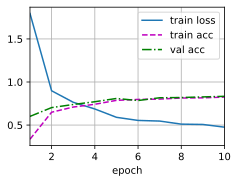

In [14]:
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
# import matplotlib.pyplot as plt

#  超参
img_size, patch_size = 96, 16
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 6
emb_dropout, blk_dropout, lr = 0.2, 0.2, 3e-4  # 推荐3e-4，可在2e-4~5e-4微调
batch_size = 128
num_epochs = 10
split_num = 10  # 分成10份，每轮取1/10数据

#  数据集预处理（原样保留） 
trans = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1))
])

# 完整数据集
full_train_data = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
full_val_data = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)

# 计算每份样本数量
train_total = len(full_train_data)
val_total = len(full_val_data)
train_split_size = train_total // split_num
val_split_size = val_total // split_num

#  模型实例化（原样保留） 
model = ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)

# 移到GPU
import d2l.torch as d2l
device = d2l.try_gpu()
model.to(device)

# 损失、优化器（原样保留）
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# 引入余弦学习率衰减
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# 训练前创建画板
animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], 
                        legend=['train loss', 'train acc', 'val acc'])

# 改造后训练循环：每轮取不同1/10分片
for epoch in range(num_epochs):
    # 每一轮epoch对应第 split_idx 分片，循环轮换 0~9
    split_idx = epoch % split_num

    # 构造当前分片下标
    train_start = split_idx * train_split_size
    train_end = train_start + train_split_size
    val_start = split_idx * val_split_size
    val_end = val_start + val_split_size

    # 取当前1/10子集
    train_subset = Subset(full_train_data, list(range(train_start, train_end)))
    val_subset = Subset(full_val_data, list(range(val_start, val_end)))

    # 加载器参数完全不变
    train_iter = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_iter = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    #  训练阶段,原逻辑不变
    model.train()
    train_loss_sum, train_acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        y_hat = model(X)
        l = loss(y_hat, y)

        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        train_loss_sum += l.item() * y.shape[0]
        train_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
        n += y.shape[0]
    train_loss = train_loss_sum / n
    train_acc = train_acc_sum / n

    #  验证阶段（原逻辑不变） 
    model.eval()
    val_acc_sum, m = 0.0, 0
    with torch.no_grad():
        for X, y in val_iter:
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            val_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
            m += y.shape[0]
    val_acc = val_acc_sum / m

    # 绘图+打印不变
    animator.add(epoch + 1, (train_loss, train_acc, val_acc))
    print(f'epoch {epoch+1} | 取第{split_idx+1}/{split_num}份数据 | train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_acc={val_acc:.4f}')

## 模型整体状态

第一次训练结果
epoch 10 | 取第10/10份数据 | train_loss=0.5057, train_acc=0.8130, val_acc=0.8350

训练损失未到0.5000以下模型未达预期
持续稳步收敛：损失持续降低、双精度同步上涨，训练有效；
仍有很大上升空间：FashionMNIST 标准 ViT 完整训练可达 90% 以上，当前验证仅 83.5%；
欠拟合为主：模型、数据遍历次数都不足。
总共 10 个 epoch，10 个子集刚好完整遍历一遍全部训练数据，只过了一轮全集，远远不够。

第二次训练结果
epoch 10 | 取第10/10份数据 | train_loss=0.4758, train_acc=0.8250, val_acc=0.8340
训练损失达标，准确率提升不高;建议提升训练数据为主

## 后续优化建议

增加epoch数量
现在只完整走了 1 次全量 6 万图片，改成 num_epochs=40~60，让 10 份数据循环多轮，精度会持续往上走。

可选扩容模型提升上限
mlp_num_hiddens=2048
num_blks=4 → 6，加深 Transformer 块

学习率优化
可以加入学习率衰减，后期逐步降低 lr，减少震荡，更容易冲到更高精度；

观察波动
继续往后跑，随着全集重复遍历次数变多，分片带来的精度波动会慢慢缩小，训练精度会逐步追上甚至超过验证精度。

